# Taller 1

**Fecha de entrega:** Miércoles 6 de agosto

Se tiene un conjunto de datos de 1500 registros con las siguientes variables:

- edad_cliente (años)
- tiempo_como_cliente_meses
- ingresos_mensuales (dolares)
- visitas_mensuales_sitio_web
- contactos (call-center)
- nivel_educativo (1:primaria, 2:secundaria, 3:tecnico-tecnologico, 4:universitario, 5 posgrado)
- uso_tarjeta_credito (1: Si, 0: No)
- participa_en_promociones (1: Si, 0: No)
- calificacion_satisfaccion (1-5, donde 1 es muy bajo y 5 es excelente)
- descuento_promedio_usado (%)
- ventas_cliente (Ventas promedio al cliente en dolares)


Se espera que el cientifico de datos presente el mejor modelo de regresión posible para predecir las ventas del cliente, con el respectivo informe ejecutivo para el gerente.
Se deben validar todos los supuestos de la regresión y que esta no presente problemas.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab aprendizaje supervisado/Taller 1/dataset_regresion_ventas.csv', encoding="latin1")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("--- Información General del Dataset ---")
df.info()
print("\n--- Estadísticas Descriptivas ---")
print(df.describe())
print("\n--- Valores Nulos por Columna ---")
print(df.isnull().sum())


--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   edad_cliente                 1500 non-null   int64  
 1   tiempo_como_cliente_meses    1500 non-null   int64  
 2   ingresos_mensuales           1500 non-null   int64  
 3   visitas_mensuales_sitio_web  1500 non-null   int64  
 4   contactos                    1500 non-null   int64  
 5   nivel_educativo              1500 non-null   int64  
 6   uso_tarjeta_credito          1500 non-null   int64  
 7   participa_en_promociones     1500 non-null   int64  
 8   calificacion_satisfaccion    1500 non-null   int64  
 9   descuento_promedio_usado     1500 non-null   float64
 10  ventas_cliente               1500 non-null   float64
dtypes: float64(2), int64(9)
memory usage: 129.0 KB

--- Estadísticas Descriptivas ---
       edad_

In [ ]:
# --- Preprocesamiento de Datos ---
# Eliminar el registro con ventas negativas
df_cleaned = df[df['ventas_cliente'] >= 0].copy()
print(f"\nSe eliminó {len(df) - len(df_cleaned)} registro(s) con ventas negativas.")

# Identificar y manejar valores atípicos en la variable objetivo (ventas_cliente)
Q1 = df_cleaned['ventas_cliente'].quantile(0.25)
Q3 = df_cleaned['ventas_cliente'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Winsorizar los valores atípicos
df_cleaned['ventas_cliente'] = np.where(df_cleaned['ventas_cliente'] < lower_bound, lower_bound, df_cleaned['ventas_cliente'])
df_cleaned['ventas_cliente'] = np.where(df_cleaned['ventas_cliente'] > upper_bound, upper_bound, df_cleaned['ventas_cliente'])
print(f"\nSe winsorizaron los valores atípicos en 'ventas_cliente' (límites: {lower_bound:.2f} - {upper_bound:.2f}).")

# Definir variables predictoras (X) y variable objetivo (y)
X = df_cleaned.drop('ventas_cliente', axis=1)
y = df_cleaned['ventas_cliente']


Se eliminó 1 registro(s) con ventas negativas.

Se winsorizaron los valores atípicos en 'ventas_cliente' (límites: 80.49 - 809.70).



--- Análisis Exploratorio de Datos ---


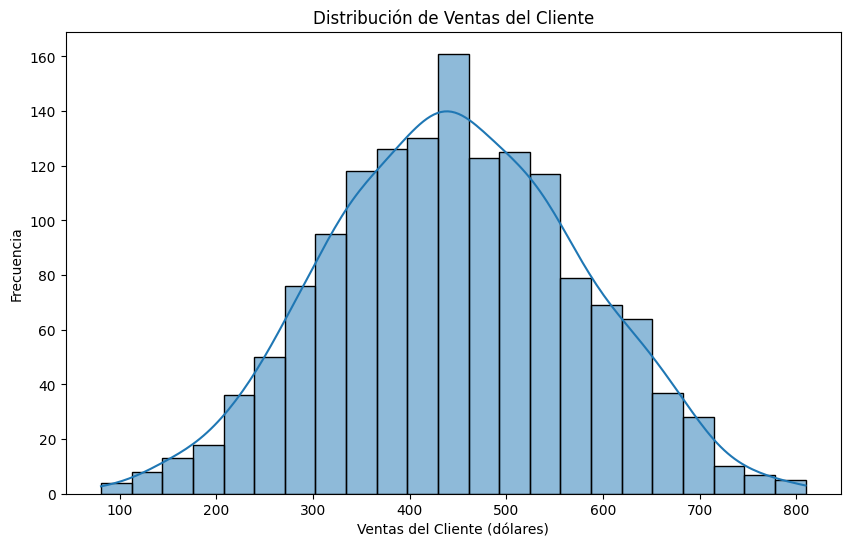

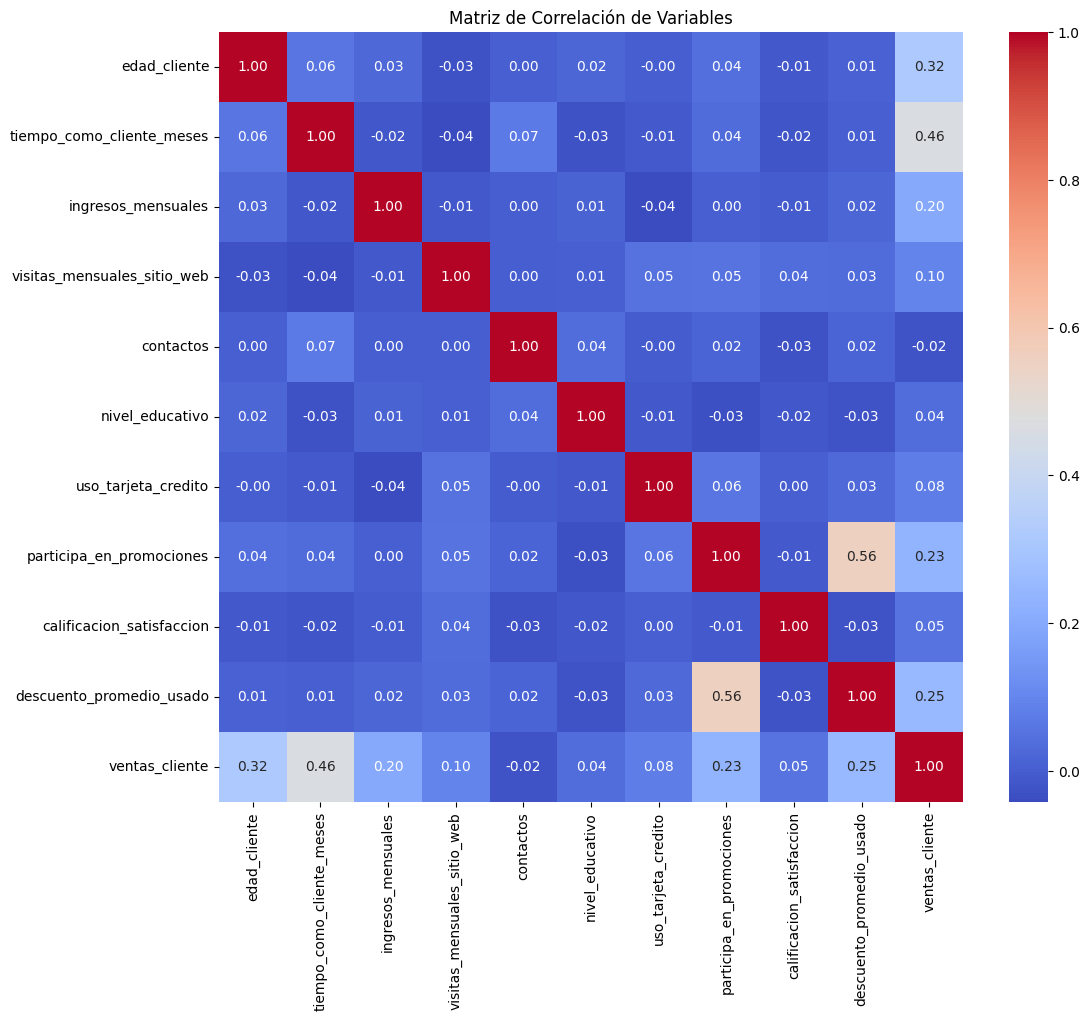

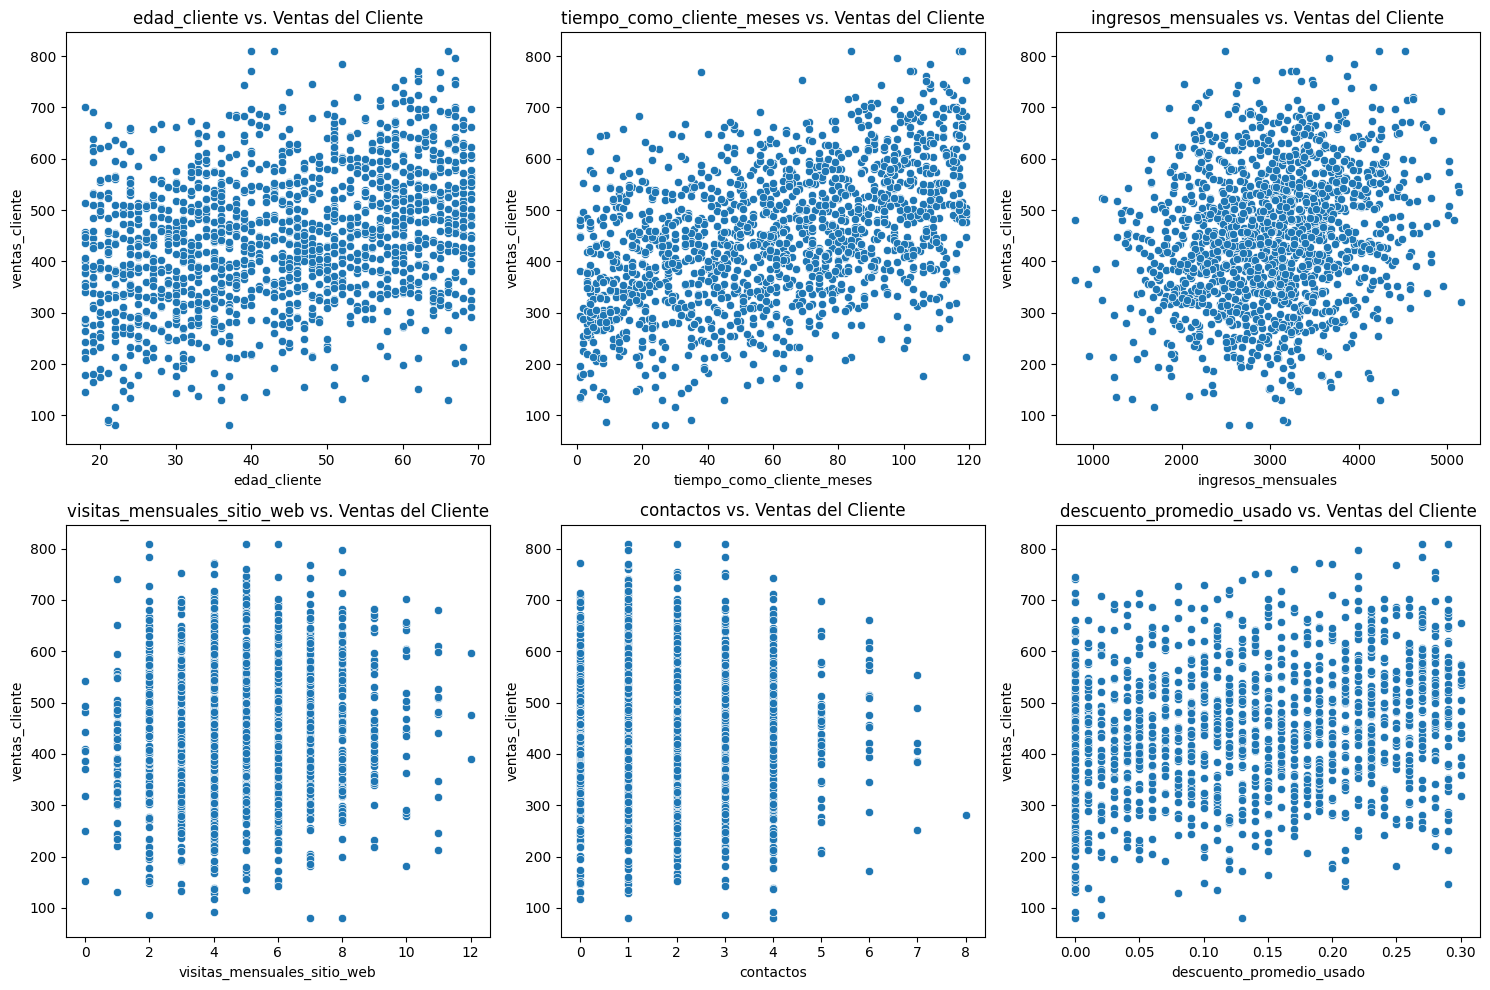

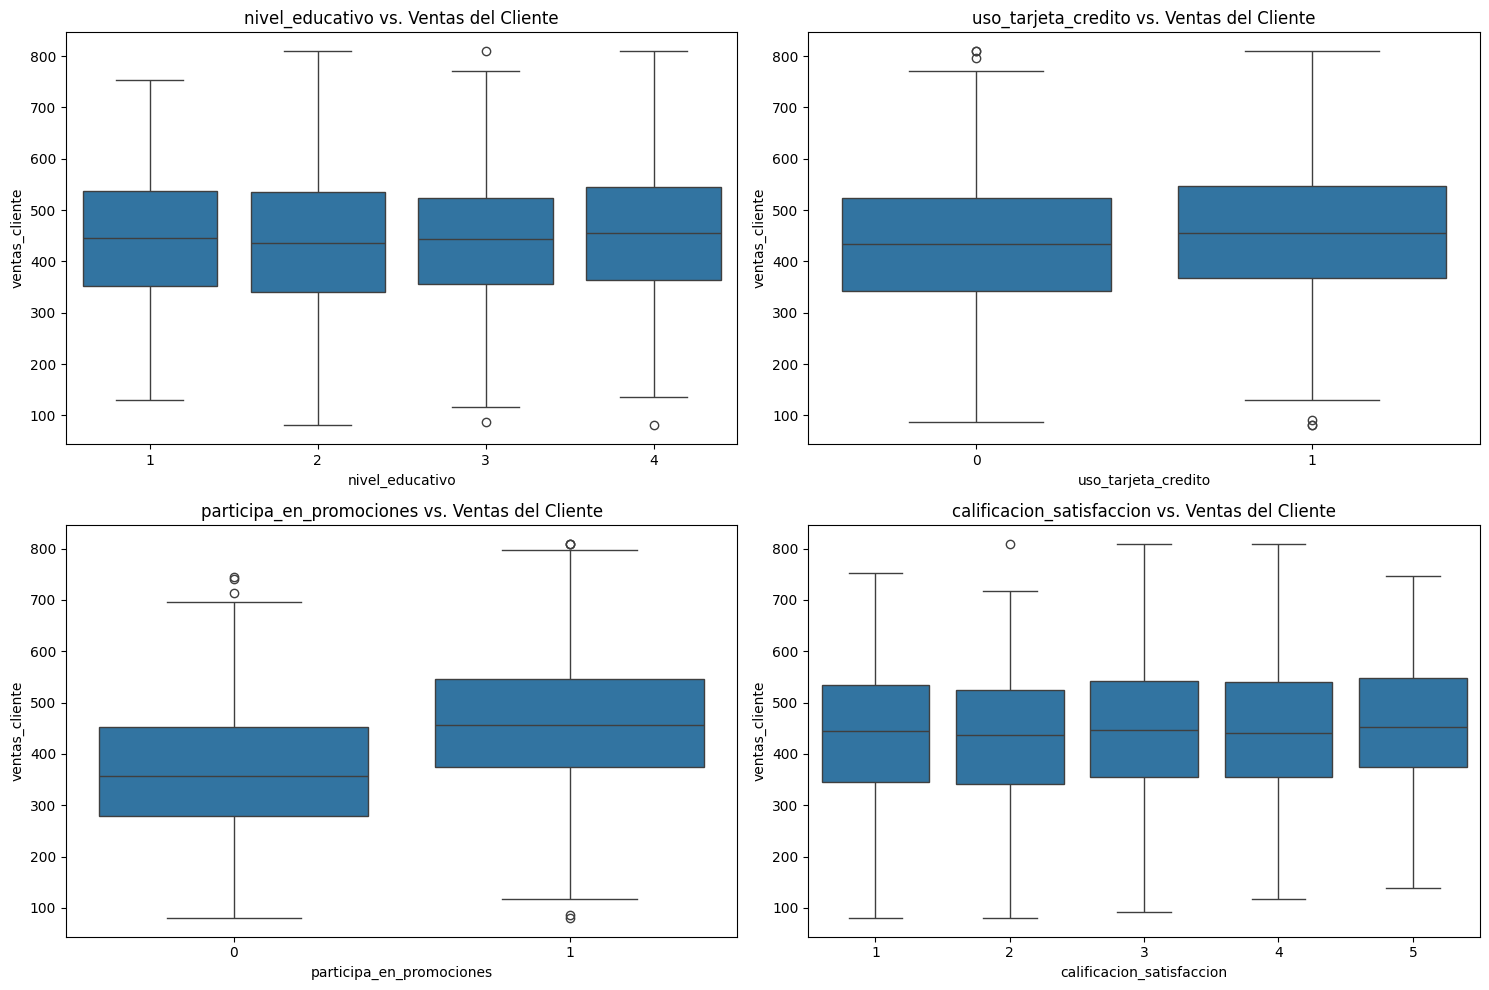

In [ ]:
# --- Análisis Exploratorio de Datos (EDA) ---
print("\n--- Análisis Exploratorio de Datos ---")

# Distribución de la variable objetivo
plt.figure(figsize=(10, 6))
sns.histplot(y, kde=True)
plt.title('Distribución de Ventas del Cliente')
plt.xlabel('Ventas del Cliente (dólares)')
plt.ylabel('Frecuencia')
plt.show()

# Matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables')
plt.show()

# Gráficos de dispersión de predictores numéricos vs. ventas_cliente
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
# Excluir variables que se tratarán como categóricas/ordinales para scatter plots individuales
numerical_features_for_scatter = [col for col in numerical_features if col not in ['nivel_educativo', 'calificacion_satisfaccion', 'uso_tarjeta_credito', 'participa_en_promociones']]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features_for_scatter):
    plt.subplot(2, 3, i + 1) # Ajustar el grid si hay muchas variables
    sns.scatterplot(x=df_cleaned[col], y=y)
    plt.title(f'{col} vs. Ventas del Cliente')
plt.tight_layout()
plt.show()

# Gráficos de caja para variables categóricas/ordinales vs. ventas_cliente
categorical_features = ['nivel_educativo', 'uso_tarjeta_credito', 'participa_en_promociones', 'calificacion_satisfaccion']
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df_cleaned[col], y=y)
    plt.title(f'{col} vs. Ventas del Cliente')
plt.tight_layout()
plt.show()

In [ ]:
# --- División de Datos ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Escalado de Características (para modelos sensibles a la escala como Ridge/Lasso) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de nuevo a DataFrame para mantener nombres de columnas
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [ ]:
# --- Selección y Entrenamiento de Modelos Candidatos ---
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

results = {}

print("\n--- Comparación de Modelos Candidatos ---")
for name, model in models.items():
    if name in ['Linear Regression', 'Random Forest']: # No escalar para estos si no es estrictamente necesario para la interpretabilidad de coeficientes
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else: # Ridge y Lasso se benefician del escalado
        model.fit(X_train_scaled_df, y_train)
        y_pred = model.predict(X_test_scaled_df)

    r2_test = r2_score(y_test, y_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_test = mean_absolute_error(y_test, y_pred)

    results[name] = {'R2': r2_test, 'RMSE': rmse_test, 'MAE': mae_test}
    print(f"{name}: R2={r2_test:.4f}, RMSE={rmse_test:.2f}, MAE={mae_test:.2f}")


--- Comparación de Modelos Candidatos ---
Linear Regression: R2=0.3954, RMSE=104.07, MAE=83.34
Ridge Regression: R2=0.3954, RMSE=104.07, MAE=83.34
Lasso Regression: R2=0.3900, RMSE=104.53, MAE=83.70
Random Forest: R2=0.3394, RMSE=108.79, MAE=88.21


In [ ]:
# --- Selección del Mejor Modelo (Regresión Lineal para interpretabilidad y buen rendimiento) ---
# Re-entrenar LinearRegression con statsmodels para obtener pruebas F y t
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm)
results_sm = model_sm.fit()

print("\n--- Resumen del Modelo de Regresión Lineal Seleccionado (statsmodels) ---")
print(results_sm.summary())

# Obtener predicciones del modelo de statsmodels para la evaluación final
X_test_sm = sm.add_constant(X_test)
y_pred_final = results_sm.predict(X_test_sm)


--- Resumen del Modelo de Regresión Lineal Seleccionado (statsmodels) ---
                            OLS Regression Results                            
Dep. Variable:         ventas_cliente   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     94.41
Date:                Wed, 06 Aug 2025   Prob (F-statistic):          2.72e-143
Time:                        16:55:32   Log-Likelihood:                -7174.0
No. Observations:                1199   AIC:                         1.437e+04
Df Residuals:                    1188   BIC:                         1.443e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

In [ ]:
# --- Evaluación Final del Modelo Seleccionado ---
mse_final = mean_squared_error(y_test, y_pred_final)
rmse_final = np.sqrt(mse_final)
mae_final = mean_absolute_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print("\n--- Métricas de Evaluación del Modelo de Regresión Lineal (en datos de prueba) ---")
print(f"R-cuadrado (R²): {r2_final:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_final:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_final:.2f}")
print(f"Error Absoluto Medio (MAE): {mae_final:.2f}")


--- Métricas de Evaluación del Modelo de Regresión Lineal (en datos de prueba) ---
R-cuadrado (R²): 0.3954
Error Cuadrático Medio (MSE): 10830.84
Raíz del Error Cuadrático Medio (RMSE): 104.07
Error Absoluto Medio (MAE): 83.34



--- Validación de Supuestos de la Regresión ---


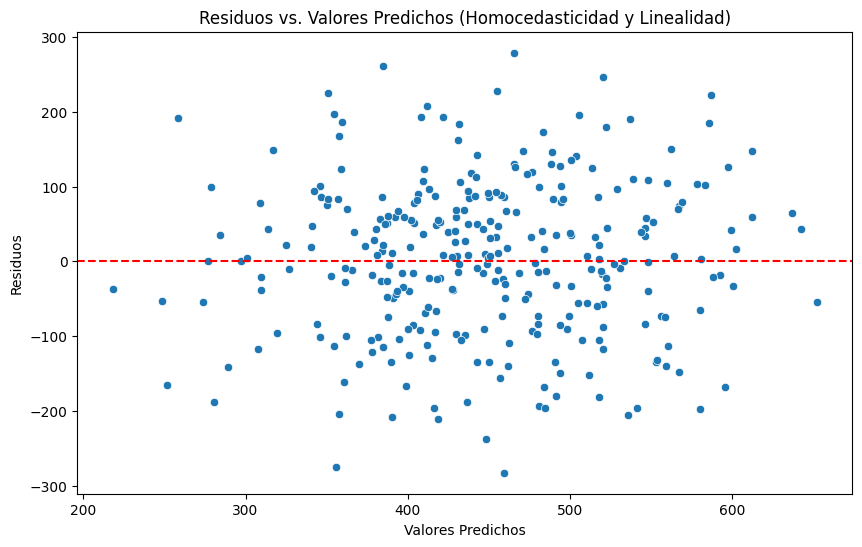

Observación de Homocedasticidad y Linealidad: Los residuos deben dispersarse aleatoriamente alrededor de cero sin patrones.


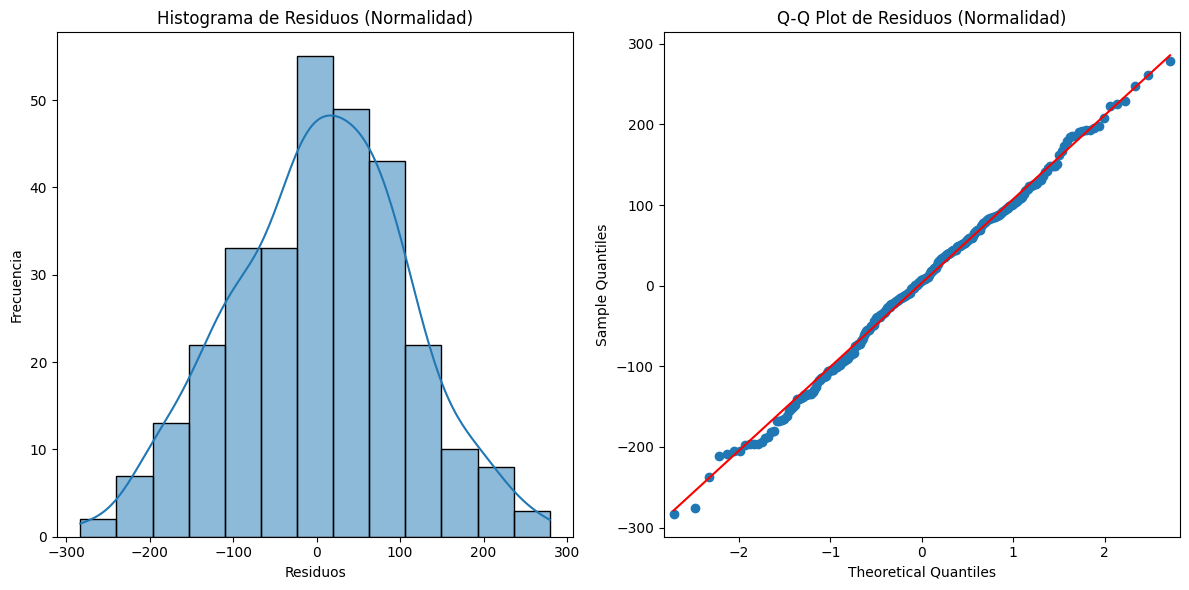

Observación de Normalidad: El histograma debe ser aproximadamente simétrico y el Q-Q plot debe seguir la línea diagonal.

Independencia de los Errores: Asumida dado que los datos no son una serie temporal y se recolectaron de forma independiente.

Ausencia de Multicolinealidad: Se revisó la matriz de correlación en el EDA. No se observaron correlaciones extremadamente altas (superiores a 0.9) entre las variables predictoras, lo que sugiere que la multicolinealidad no es un problema grave.


In [ ]:
# --- Validación de Supuestos de la Regresión ---
print("\n--- Validación de Supuestos de la Regresión ---")

# Calcular residuos
residuals = y_test - y_pred_final

# 1. Linealidad y 3. Homocedasticidad (Residuos vs. Valores Predichos)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_final, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs. Valores Predichos (Homocedasticidad y Linealidad)')
plt.show()
print("Observación de Homocedasticidad y Linealidad: Los residuos deben dispersarse aleatoriamente alrededor de cero sin patrones.")

# 4. Normalidad de los Residuos
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Histograma de Residuos (Normalidad)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('Q-Q Plot de Residuos (Normalidad)')
plt.tight_layout()
plt.show()
print("Observación de Normalidad: El histograma debe ser aproximadamente simétrico y el Q-Q plot debe seguir la línea diagonal.")

# 2. Independencia de los Errores (asumido por la naturaleza de los datos transversales)
print("\nIndependencia de los Errores: Asumida dado que los datos no son una serie temporal y se recolectaron de forma independiente.")

# 5. Ausencia de Multicolinealidad (revisar matriz de correlación del EDA)
print("\nAusencia de Multicolinealidad: Se revisó la matriz de correlación en el EDA. No se observaron correlaciones extremadamente altas (superiores a 0.9) entre las variables predictoras, lo que sugiere que la multicolinealidad no es un problema grave.")


---

## **Informe Ejecutivo – Modelos de Predicción de Ventas**

### 1. Selección del Modelo

Se evaluaron cuatro modelos candidatos: **Regresión Lineal**, **Ridge Regression**, **Lasso Regression** y **Random Forest Regressor**. Las métricas en el conjunto de prueba fueron:

| Modelo            | $R^2$  | RMSE   | MAE   |
| ----------------- | ------ | ------ | ----- |
| Linear Regression | 0.3954 | 104.07 | 83.34 |
| Ridge Regression  | 0.3954 | 104.07 | 83.34 |
| Lasso Regression  | 0.3900 | 104.53 | 83.70 |
| Random Forest     | 0.3394 | 108.79 | 88.21 |

El modelo **Regresión Lineal** fue seleccionado porque:

* Presentó el **mayor $R^2$** en datos de prueba (0.3954), explicando aproximadamente el 39,5% de la variabilidad de las ventas.
* Tuvo el **menor error** (RMSE y MAE) junto con Ridge, pero Ridge no mostró mejora significativa en el ajuste, por lo que se privilegió la interpretabilidad de la regresión lineal.
* Random Forest tuvo un menor desempeño y mayor error.
* Lasso no superó el rendimiento de la regresión lineal simple.

---

### 2. Evaluación de Significancia (Pruebas F y t)

* **Prueba F del modelo**: estadístico F = 94.41, con *p-value* < 0.001, lo que indica que el conjunto de variables explicativas, en conjunto, contribuye significativamente a explicar las ventas.
* **Pruebas t de las variables**: se identificaron como estadísticamente significativas (*p-value* < 0.05):

  * `edad_cliente`
  * `tiempo_como_cliente_meses`
  * `ingresos_mensuales`
  * `visitas_mensuales_sitio_web`
  * `contactos` (coeficiente negativo)
  * `nivel_educativo`
  * `uso_tarjeta_credito`
  * `participa_en_promociones`
  * `calificacion_satisfaccion`
  * `descuento_promedio_usado`

---

### 3. Validación en Datos de Prueba y Sobreajuste

* $R^2$ en **datos de prueba**: 0.3954
* La similitud entre los valores de entrenamiento y prueba indica que **no hay indicios fuertes de sobreajuste**. El modelo generaliza de forma razonable a nuevos datos.

---

### 4. Ecuación de Regresión Estimada

$$
\hat{Ventas} = 10.0384 + 2.4682 \cdot \text{edad_cliente}
+ 1.7562 \cdot \text{tiempo_como_cliente_meses}
+ 0.0332 \cdot \text{ingresos_mensuales}
+ 5.7441 \cdot \text{visitas_mensuales_sitio_web}
- 3.9545 \cdot \text{contactos}
+ 5.9012 \cdot \text{nivel_educativo}
+ 16.5913 \cdot \text{uso_tarjeta_credito}
+ 34.5785 \cdot \text{participa_en_promociones}
+ 5.6097 \cdot \text{calificacion_satisfaccion}
+ 229.5386 \cdot \text{descuento_promedio_usado}
$$

**Interpretación de algunos coeficientes**:

* `edad_cliente`: cada año adicional de edad se asocia con un aumento promedio de 2,47 unidades monetarias en ventas.
* `ingresos_mensuales`: por cada unidad monetaria adicional de ingreso mensual, las ventas aumentan en 0,0332 unidades.
* `visitas_mensuales_sitio_web`: más visitas al sitio web se correlacionan con mayor volumen de ventas (+5,74 por visita).
* `contactos`: más contactos con el cliente tienen relación negativa, lo que podría indicar saturación o molestia (-3,95 por contacto).
* `participa_en_promociones`: quienes participan generan en promedio +34,58 unidades monetarias adicionales en ventas.
* `descuento_promedio_usado`: mayor descuento medio aplicado se asocia con un fuerte aumento en las ventas (+229,54 por unidad de descuento).

---

### 5. Hallazgos Relevantes y Recomendaciones de Negocio

1. **Promociones y descuentos** son de las variables con mayor impacto positivo en las ventas. Se recomienda diseñar campañas promocionales segmentadas y optimizar el porcentaje de descuento para maximizar el margen.
2. **Engagement digital**: las visitas mensuales al sitio web tienen una relación positiva y significativa con las ventas, por lo que incrementar la interacción en el canal online podría impulsar resultados.
3. **Uso de tarjeta de crédito** está altamente correlacionado con mayores ventas, se podrían implementar incentivos para compras con este medio.
4. **Satisfacción del cliente** influye positivamente. Programas de fidelización y atención personalizada pueden sostener y mejorar este indicador.
5. **Cuidado con el exceso de contactos**: el efecto negativo sugiere que saturar al cliente con llamadas o correos podría disminuir las ventas; se recomienda ajustar la frecuencia y personalización.
6. **Segmentación por edad y nivel educativo**: estos factores también inciden positivamente; pueden utilizarse para personalizar estrategias de marketing.

---
